# DSCI 552 – Homework 2

**Name:** Manjula  
**Course:** DSCI 552  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

sns.set_theme(style="whitegrid")

# Question 1 — Combined Cycle Power Plant Dataset

## 1(a) Download and load the dataset

The Combined Cycle Power Plant dataset was obtained from the UCI Machine
Learning Repository. The Excel workbook contains five shuffled versions of
the same dataset. Following the assignment instructions, only the first
worksheet is used.

In [2]:
file_path = "Manjula_HW2/CCPP/Folds5x2_pp.xlsx"

df = pd.read_excel(file_path, sheet_name=0)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

Dataset shape: (9568, 5)
Columns: ['AT', 'V', 'AP', 'RH', 'PE']


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## 1(b) Exploring the Data

### 1(b)(i) Dataset dimensions

The dataset contains 9,568 rows and 5 columns. Each row represents one
hourly observation collected from the Combined Cycle Power Plant while it
was operating at full load.

The columns represent four predictor variables and one response variable:

- **AT:** Ambient Temperature
- **V:** Exhaust Vacuum
- **AP:** Ambient Pressure
- **RH:** Relative Humidity
- **PE:** Net hourly electrical energy output, which is the response variable

### 1(b)(ii) Pairwise scatterplots

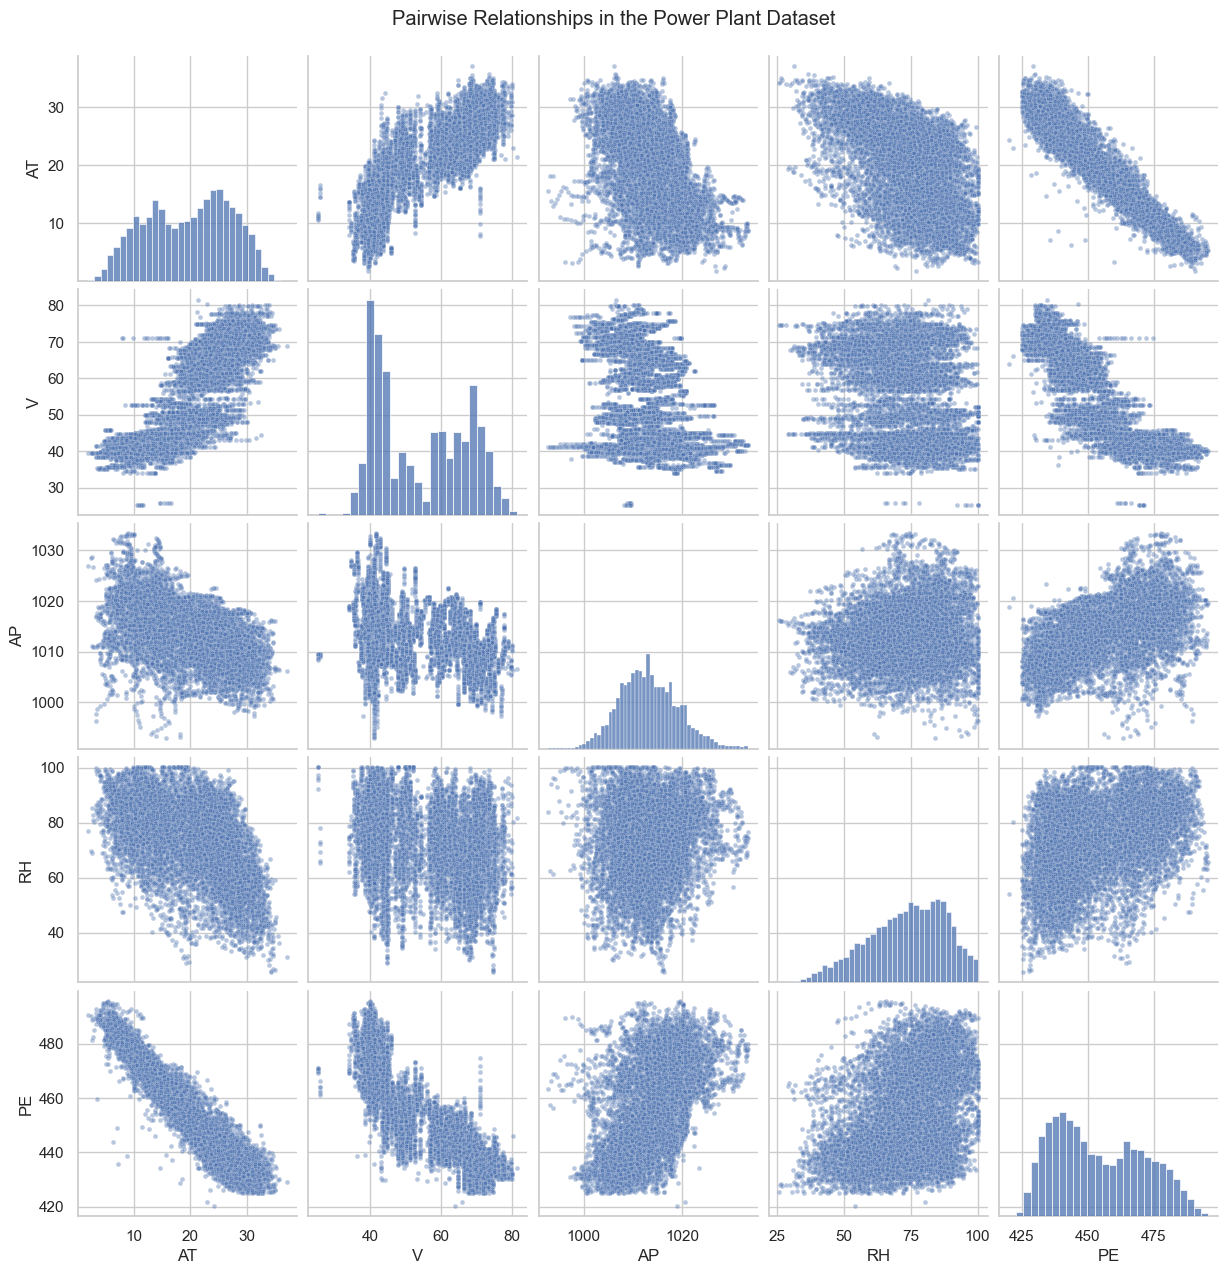

In [3]:
pair_plot = sns.pairplot(
    df,
    diag_kind="hist",
    plot_kws={"alpha": 0.4, "s": 12}
)

pair_plot.fig.suptitle(
    "Pairwise Relationships in the Power Plant Dataset",
    y=1.02
)

plt.show()

#### Pairplot interpretation

The pairwise scatterplots show that ambient temperature (AT) has a strong negative association with electrical energy output (PE). As AT increases, PE decreases. The relationship appears slightly nonlinear.

Exhaust vacuum (V) has a negative association with PE, although the observations form several clusters. Ambient pressure (AP) has a weaker positive association with PE. Relative humidity (RH) has a weak positive association with PE and shows considerable variability.

Some predictors are also associated with one another. AT and V have a positive relationship, while AT has negative relationships with AP and RH. These relationships suggest that the predictor variables are not completely independent. A few unusual observations are visible, but formal regression diagnostics are needed before deciding whether any observations should be considered influential or removed.

### 1(b)(iii) Summary Statistics

In [4]:
summary_table = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Minimum": df.min(),
    "Maximum": df.max(),
    "Range": df.max() - df.min(),
    "First Quartile (Q1)": df.quantile(0.25),
    "Third Quartile (Q3)": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25)
})

summary_table.round(2)

,Mean,Median,Minimum,Maximum,Range,First Quartile (Q1),Third Quartile (Q3),IQR
AT,19.65,20.34,1.81,37.11,35.30,13.51,25.72,12.21
V,54.31,52.08,25.36,81.56,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,992.89,1033.30,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,25.56,100.16,74.60,63.33,84.83,21.50
PE,454.37,451.55,420.26,495.76,75.50,439.75,468.43,28.68


## 1(c) Simple Linear Regression

A separate simple linear regression model is fitted for each predictor to
predict electrical energy output (PE).

In [5]:
predictors = ["AT", "V", "AP", "RH"]

simple_models = {}
simple_results = []

for predictor in predictors:
    model = smf.ols(formula=f"PE ~ {predictor}", data=df).fit()
    simple_models[predictor] = model

    simple_results.append({
        "Predictor": predictor,
        "Intercept": model.params["Intercept"],
        "Coefficient": model.params[predictor],
        "P-value": model.pvalues[predictor],
        "R-squared": model.rsquared
    })

simple_results_df = pd.DataFrame(simple_results)
simple_results_df.round(4)

,Predictor,Intercept,Coefficient,P-value,R-squared
0,AT,497.0341,-2.1713,0.0,0.8989
1,V,517.8015,-1.1681,0.0,0.7565
2,AP,-1055.2610,1.4899,0.0,0.2688
3,RH,420.9618,0.4557,0.0,0.1519


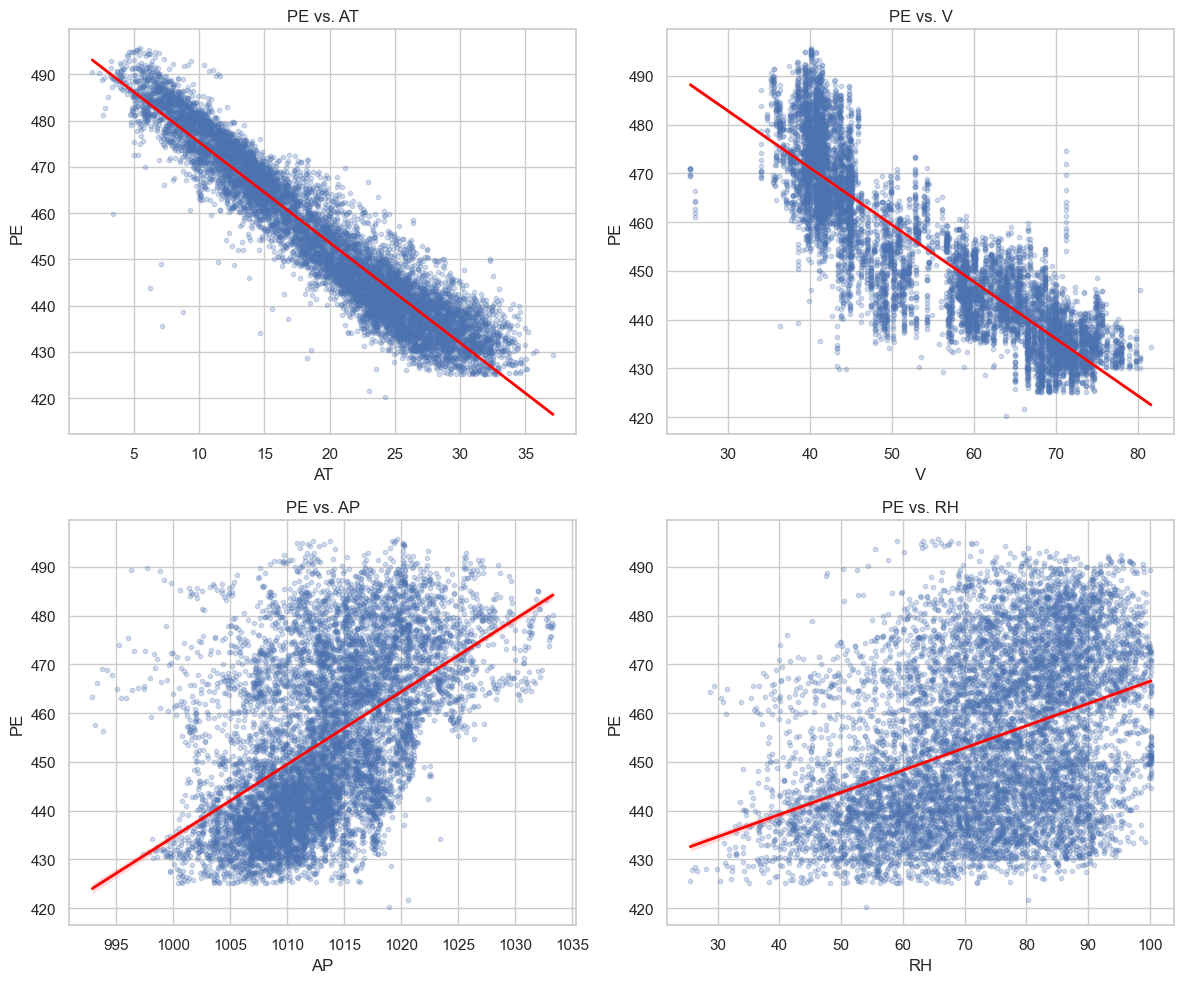

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for predictor, ax in zip(predictors, axes.flatten()):
    sns.regplot(
        data=df,
        x=predictor,
        y="PE",
        scatter_kws={"alpha": 0.25, "s": 10},
        line_kws={"color": "red", "linewidth": 2},
        ax=ax
    )

    ax.set_title(f"PE vs. {predictor}")

plt.tight_layout()
plt.show()

In [7]:
simple_results_df.round(4)

,Predictor,Intercept,Coefficient,P-value,R-squared
0,AT,497.0341,-2.1713,0.0,0.8989
1,V,517.8015,-1.1681,0.0,0.7565
2,AP,-1055.2610,1.4899,0.0,0.2688
3,RH,420.9618,0.4557,0.0,0.1519


### Simple linear regression results

All four predictors have statistically significant associations with PE
because their p-values are below 0.05.

- **AT:** The estimated coefficient is -2.1713. A one-unit increase in AT is
  associated with an average decrease of approximately 2.17 units in PE.
  The model has an R² of 0.8989, so AT alone explains approximately 89.89%
  of the variation in PE.

- **V:** The estimated coefficient is -1.1681. A one-unit increase in V is
  associated with an average decrease of approximately 1.17 units in PE.
  The model explains approximately 75.65% of the variation in PE.

- **AP:** The estimated coefficient is 1.4899. A one-unit increase in AP is
  associated with an average increase of approximately 1.49 units in PE.
  The model explains approximately 26.88% of the variation in PE.

- **RH:** The estimated coefficient is 0.4557. A one-unit increase in RH is
  associated with an average increase of approximately 0.46 units in PE.
  The model explains approximately 15.19% of the variation in PE.

AT is the strongest individual predictor because its simple regression model
has the largest R². RH is the weakest individual predictor. Statistical
significance does not necessarily imply strong predictive ability; AP and RH
are statistically significant but have comparatively low R² values.

In [8]:
outlier_summary = []

for predictor, model in simple_models.items():
    influence = model.get_influence()

    studentized_residuals = influence.resid_studentized_external
    cooks_distance = influence.cooks_distance[0]

    residual_outliers = np.abs(studentized_residuals) > 3
    influential_points = cooks_distance > (4 / len(df))

    outlier_summary.append({
        "Predictor": predictor,
        "|Studentized residual| > 3": residual_outliers.sum(),
        "Cook's distance > 4/n": influential_points.sum(),
        "Maximum Cook's distance": cooks_distance.max()
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df.round(4)

,Predictor,|Studentized residual| > 3,Cook's distance > 4/n,Maximum Cook's distance
0,AT,42,416,0.0143
1,V,33,423,0.0032
2,AP,30,300,0.0082
3,RH,2,249,0.0021


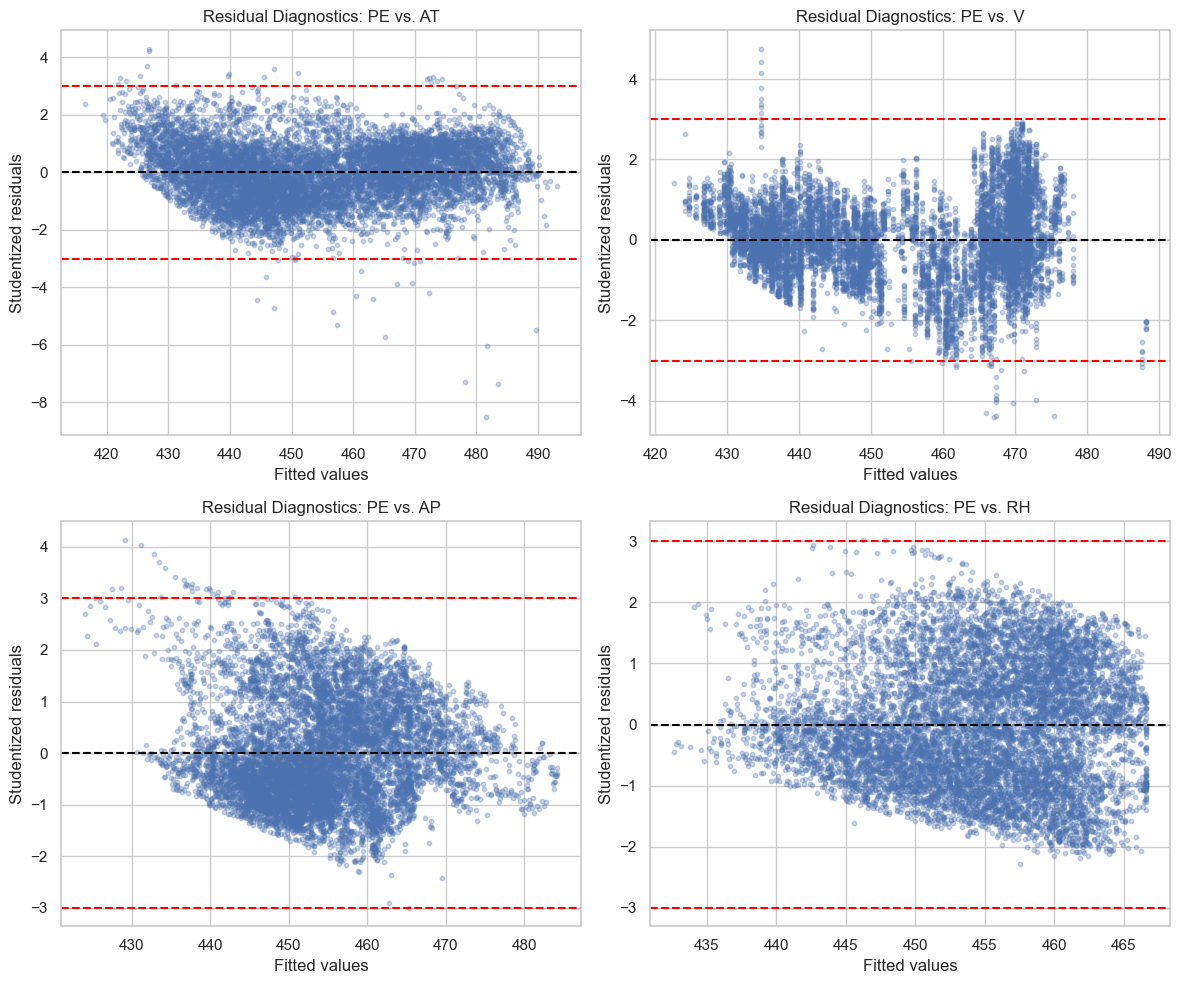

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for predictor, ax in zip(predictors, axes.flatten()):
    model = simple_models[predictor]
    influence = model.get_influence()
    studentized_residuals = influence.resid_studentized_external

    ax.scatter(
        model.fittedvalues,
        studentized_residuals,
        alpha=0.3,
        s=10
    )

    ax.axhline(0, color="black", linestyle="--")
    ax.axhline(3, color="red", linestyle="--")
    ax.axhline(-3, color="red", linestyle="--")
    ax.set_title(f"Residual Diagnostics: PE vs. {predictor}")
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Studentized residuals")

plt.tight_layout()
plt.show()

### Outlier and residual analysis

The studentized-residual plots identify several observations with absolute
studentized residuals greater than 3, particularly in the models using AT,
V, and AP. These observations are potential outliers. The residual plots
also contain structured patterns rather than completely random scatter,
suggesting possible nonlinearity and nonconstant error variance.

However, the unusual observations should not be removed automatically.
There is no evidence that they resulted from measurement or data-entry
errors, and this dataset contains legitimate power-plant operating
conditions. Therefore, I retain all observations for the subsequent
analyses. The possible nonlinear relationships will be investigated in
Question 1(f).

## 1(d) Multiple Linear Regression

In [10]:
multiple_model = smf.ols(
    formula="PE ~ AT + V + AP + RH",
    data=df
).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:59:14   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

In [11]:
multiple_results = pd.DataFrame({
    "Coefficient": multiple_model.params,
    "Standard Error": multiple_model.bse,
    "t-statistic": multiple_model.tvalues,
    "P-value": multiple_model.pvalues
})

display(multiple_results.round(4))

print("R-squared:", round(multiple_model.rsquared, 4))
print("Adjusted R-squared:", round(multiple_model.rsquared_adj, 4))

,Coefficient,Standard Error,t-statistic,P-value
Intercept,454.6093,9.7485,46.6337,0.0
AT,-1.9775,0.0153,-129.3420,0.0
V,-0.2339,0.0073,-32.1221,0.0
AP,0.0621,0.0095,6.5641,0.0
RH,-0.1581,0.0042,-37.9185,0.0


R-squared: 0.9287
Adjusted R-squared: 0.9287


### Multiple linear regression results

The multiple linear regression model has an R² and adjusted R² of 0.9287.
Therefore, AT, V, AP, and RH jointly explain approximately 92.87% of the
variation in electrical energy output.

All four predictors have p-values below 0.05. Therefore, the null hypothesis
H₀: βⱼ = 0 is rejected for AT, V, AP, and RH. Each predictor has a
statistically significant association with PE after controlling for the
other predictors.

Holding the other predictors constant:

- A one-unit increase in AT is associated with a 1.9775-unit decrease in PE.
- A one-unit increase in V is associated with a 0.2339-unit decrease in PE.
- A one-unit increase in AP is associated with a 0.0621-unit increase in PE.
- A one-unit increase in RH is associated with a 0.1581-unit decrease in PE.

The sign of the RH coefficient differs from its coefficient in the simple
linear regression model. This indicates that the marginal relationship
between RH and PE is affected by its relationships with the other
predictors.

## 1(e) Comparison of Simple and Multiple Regression Coefficients

In [12]:
coefficient_comparison = pd.DataFrame({
    "Predictor": predictors,
    "Simple coefficient": [
        simple_models[predictor].params[predictor]
        for predictor in predictors
    ],
    "Multiple coefficient": [
        multiple_model.params[predictor]
        for predictor in predictors
    ]
})

display(coefficient_comparison.round(4))

,Predictor,Simple coefficient,Multiple coefficient
0,AT,-2.1713,-1.9775
1,V,-1.1681,-0.2339
2,AP,1.4899,0.0621
3,RH,0.4557,-0.1581


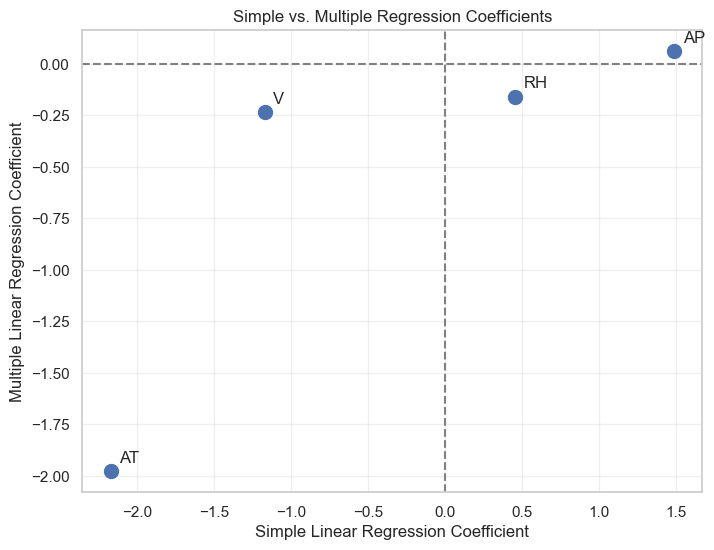

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    coefficient_comparison["Simple coefficient"],
    coefficient_comparison["Multiple coefficient"],
    s=100
)

for _, row in coefficient_comparison.iterrows():
    plt.annotate(
        row["Predictor"],
        (
            row["Simple coefficient"],
            row["Multiple coefficient"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")

plt.xlabel("Simple Linear Regression Coefficient")
plt.ylabel("Multiple Linear Regression Coefficient")
plt.title("Simple vs. Multiple Regression Coefficients")
plt.grid(alpha=0.3)
plt.show()

The coefficients from the simple and multiple regression models differ
because each simple regression examines one predictor by itself, whereas
the multiple regression estimates each predictor's association with PE
while controlling for all other predictors.

The AT coefficient changes relatively little and remains strongly negative.
The magnitudes of the V and AP coefficients become substantially smaller in
the multiple regression model. Most notably, the RH coefficient changes
from positive in the simple regression model to negative in the multiple
regression model. This change suggests confounding among the predictors,
which is consistent with the correlations observed in the pairplot.

## 1(f) Nonlinear Associations

For each predictor, a cubic polynomial regression model is fitted:

$$
PE = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \epsilon
$$

The p-values of the quadratic and cubic terms are used to determine whether
there is evidence of a nonlinear association.

In [14]:
polynomial_models = {}
polynomial_results = []

for predictor in predictors:
    formula = (
        f"PE ~ {predictor} + "
        f"I({predictor} ** 2) + "
        f"I({predictor} ** 3)"
    )

    model = smf.ols(formula=formula, data=df).fit()
    polynomial_models[predictor] = model

    polynomial_results.append({
        "Predictor": predictor,
        "Linear p-value": model.pvalues[predictor],
        "Quadratic p-value": model.pvalues[f"I({predictor} ** 2)"],
        "Cubic p-value": model.pvalues[f"I({predictor} ** 3)"],
        "R-squared": model.rsquared
    })

polynomial_results_df = pd.DataFrame(polynomial_results)
display(polynomial_results_df)

,Predictor,Linear p-value,Quadratic p-value,Cubic p-value,R-squared
0,AT,7.898147e-07,8.833045e-73,3.652185e-110,0.911883
1,V,2.526589e-05,7.684969e-01,1.373489e-02,0.775022
2,AP,4.502735e-17,3.666705e-17,8.264146e-18,0.274863
3,RH,3.772510e-04,9.395430e-06,1.440279e-05,0.153743


In [15]:
polynomial_results_df.style.format({
    "Linear p-value": "{:.3e}",
    "Quadratic p-value": "{:.3e}",
    "Cubic p-value": "{:.3e}",
    "R-squared": "{:.4f}"
})

,Predictor,Linear p-value,Quadratic p-value,Cubic p-value,R-squared
0,AT,7.898e-07,8.833e-73,3.652e-110,0.9119
1,V,2.527e-05,7.685e-01,1.373e-02,0.7750
2,AP,4.503e-17,3.667e-17,8.264e-18,0.2749
3,RH,3.773e-04,9.395e-06,1.440e-05,0.1537


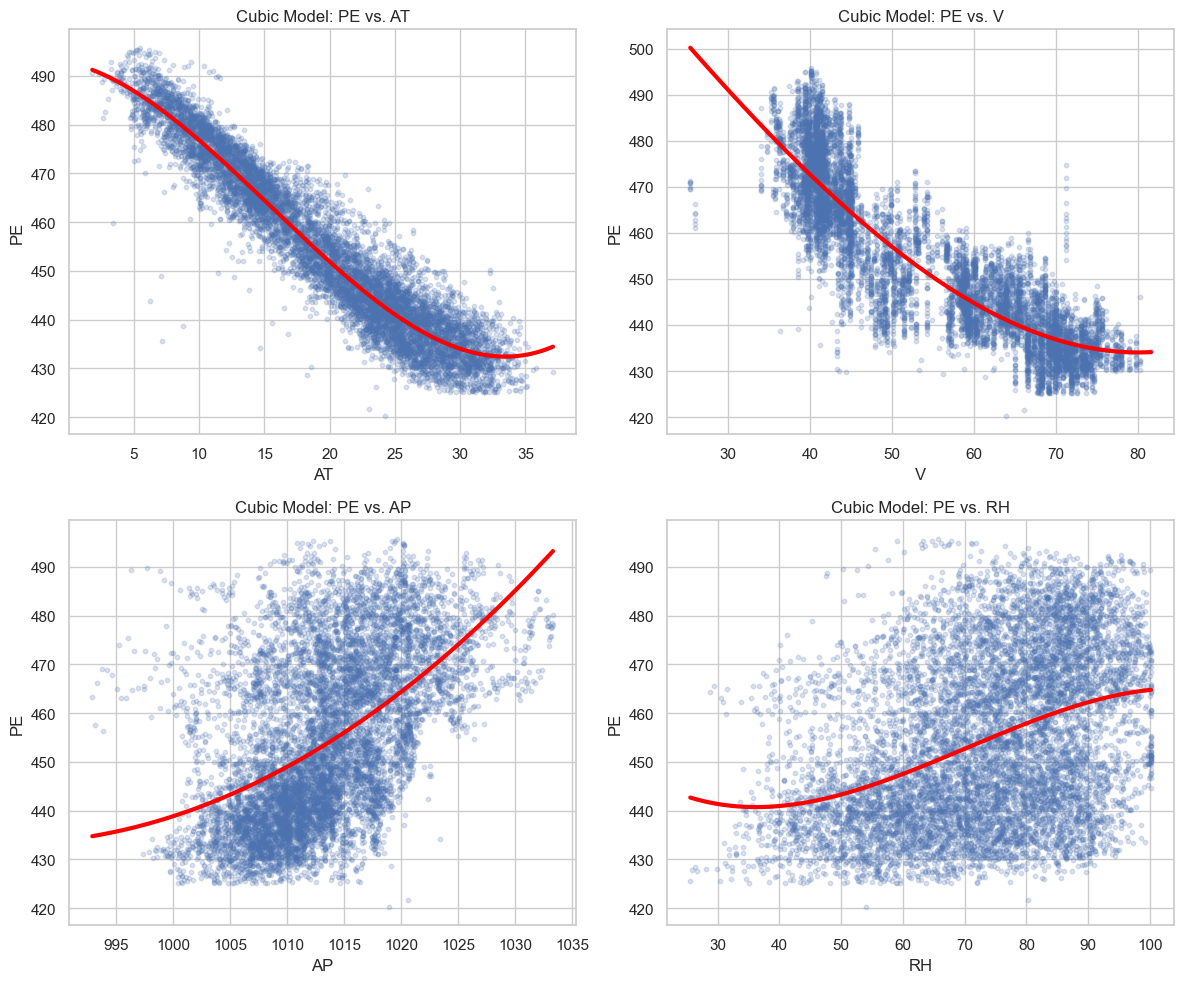

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for predictor, ax in zip(predictors, axes.flatten()):
    model = polynomial_models[predictor]

    x_values = np.linspace(
        df[predictor].min(),
        df[predictor].max(),
        300
    )

    prediction_data = pd.DataFrame({
        predictor: x_values
    })

    predicted_pe = model.predict(prediction_data)

    ax.scatter(
        df[predictor],
        df["PE"],
        alpha=0.2,
        s=10
    )

    ax.plot(
        x_values,
        predicted_pe,
        color="red",
        linewidth=3
    )

    ax.set_title(f"Cubic Model: PE vs. {predictor}")
    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")

plt.tight_layout()
plt.show()

### Nonlinear-association results

There is evidence of nonlinear association between each predictor and PE.

- **AT:** Both the quadratic term (p = 8.833 × 10⁻⁷³) and cubic term
  (p = 3.652 × 10⁻¹¹⁰) are statistically significant. Therefore, there is
  strong evidence of a nonlinear association between AT and PE.

- **V:** The quadratic term is not statistically significant
  (p = 0.7685), but the cubic term is statistically significant
  (p = 0.01373). Therefore, there is evidence of a nonlinear association,
  although it is weaker than the evidence observed for AT. The quadratic
  term remains in the cubic model to preserve model hierarchy.

- **AP:** Both the quadratic term (p = 3.667 × 10⁻¹⁷) and cubic term
  (p = 8.264 × 10⁻¹⁸) are statistically significant. Therefore, there is
  evidence of a nonlinear association between AP and PE.

- **RH:** Both the quadratic term (p = 9.395 × 10⁻⁶) and cubic term
  (p = 1.440 × 10⁻⁵) are statistically significant. Therefore, there is
  evidence of a nonlinear association between RH and PE.

The cubic AT model has the highest R² of 0.9119. However, these models were
fitted separately, so the R² values should not be interpreted as the effects
of the predictors after controlling for the other predictors.

## 1(g) Pairwise Interactions

In [17]:
interaction_model = smf.ols(
    formula="PE ~ (AT + V + AP + RH) ** 2",
    data=df
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:59:15   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

In [18]:
interaction_terms = [
    term for term in interaction_model.params.index
    if ":" in term
]

interaction_results = pd.DataFrame({
    "Interaction": interaction_terms,
    "Coefficient": [
        interaction_model.params[term]
        for term in interaction_terms
    ],
    "P-value": [
        interaction_model.pvalues[term]
        for term in interaction_terms
    ]
})

display(
    interaction_results.style.format({
        "Coefficient": "{:.6f}",
        "P-value": "{:.3e}"
    })
)

,Interaction,Coefficient,P-value
0,AT:V,0.020971,3.333e-117
1,AT:AP,0.001759,4.521e-01
2,AT:RH,-0.005230,1.217e-10
3,V:AP,0.006812,2.877e-07
4,V:RH,0.000839,8.619e-02
5,AP:RH,-0.001612,3.361e-02


### Pairwise-interaction results

The model containing all main effects and pairwise interactions has an R²
of approximately 0.936. Using a significance level of 0.05, the following
interaction terms are statistically significant:

- AT × V: p = 3.333 × 10⁻¹¹⁷
- AT × RH: p = 1.217 × 10⁻¹⁰
- V × AP: p = 2.877 × 10⁻⁷
- AP × RH: p = 0.03361

The following interactions are not statistically significant:

- AT × AP: p = 0.4521
- V × RH: p = 0.08619

Therefore, there is evidence that several predictors interact in their
association with PE. For example, the relationship between AT and PE depends
on V and RH. Similarly, the relationship between V and PE depends on AP, and
the relationship between AP and PE depends on RH.

## 1(h) Comparison of Linear and Expanded Regression Models

In [19]:
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42
)

print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))

Training observations: 6697
Testing observations: 2871


In [20]:
baseline_model = smf.ols(
    formula="PE ~ AT + V + AP + RH",
    data=train_df
).fit()

baseline_train_predictions = baseline_model.predict(train_df)
baseline_test_predictions = baseline_model.predict(test_df)

baseline_train_mse = mean_squared_error(
    train_df["PE"],
    baseline_train_predictions
)

baseline_test_mse = mean_squared_error(
    test_df["PE"],
    baseline_test_predictions
)

print("Baseline training MSE:", round(baseline_train_mse, 4))
print("Baseline test MSE:", round(baseline_test_mse, 4))

Baseline training MSE: 20.5808
Baseline test MSE: 21.2399


In [21]:
main_effects = ["AT", "V", "AP", "RH"]

higher_order_terms = [
    "I(AT ** 2)",
    "I(V ** 2)",
    "I(AP ** 2)",
    "I(RH ** 2)",
    "AT:V",
    "AT:AP",
    "AT:RH",
    "V:AP",
    "V:RH",
    "AP:RH"
]

selected_terms = higher_order_terms.copy()

while True:
    formula = (
        "PE ~ "
        + " + ".join(main_effects + selected_terms)
    )

    selected_model = smf.ols(
        formula=formula,
        data=train_df
    ).fit()

    selected_pvalues = selected_model.pvalues[selected_terms]
    largest_pvalue = selected_pvalues.max()

    if largest_pvalue <= 0.05:
        break

    term_to_remove = selected_pvalues.idxmax()

    print(
        f"Removing {term_to_remove}: "
        f"p-value = {largest_pvalue:.4f}"
    )

    selected_terms.remove(term_to_remove)

print("\nFinal higher-order terms:")
print(selected_terms)

print("\nFinal model summary:")
print(selected_model.summary())

Removing V:RH: p-value = 0.8674
Removing I(V ** 2): p-value = 0.6077
Removing V:AP: p-value = 0.3578

Final higher-order terms:
['I(AT ** 2)', 'I(AP ** 2)', 'I(RH ** 2)', 'AT:V', 'AT:AP', 'AT:RH', 'AP:RH']

Final model summary:
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9258.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:59:15   Log-Likelihood:                -19161.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6685   BIC:                         3.843e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                        

In [22]:
expanded_train_predictions = selected_model.predict(train_df)
expanded_test_predictions = selected_model.predict(test_df)

expanded_train_mse = mean_squared_error(
    train_df["PE"],
    expanded_train_predictions
)

expanded_test_mse = mean_squared_error(
    test_df["PE"],
    expanded_test_predictions
)

model_comparison = pd.DataFrame({
    "Model": [
        "Standard linear regression",
        "Selected expanded regression"
    ],
    "Training MSE": [
        baseline_train_mse,
        expanded_train_mse
    ],
    "Test MSE": [
        baseline_test_mse,
        expanded_test_mse
    ]
})

display(model_comparison.round(4))

,Model,Training MSE,Test MSE
0,Standard linear regression,20.5808,21.2399
1,Selected expanded regression,17.8908,18.6600


### Model-comparison results

The standard multiple linear regression model produced a training MSE of
20.5808 and a test MSE of 21.2399.

Backward elimination removed the following insignificant higher-order terms:

- V × RH
- V²
- V × AP

The final expanded model retained all four main effects, the quadratic terms
AT², AP², and RH², and the interactions AT × V, AT × AP, AT × RH, and
AP × RH. The main effects were retained to preserve model hierarchy.

The selected expanded model produced a training MSE of 17.8908 and a test
MSE of 18.6600. Its test MSE is approximately 12.15% lower than that of the
standard linear model. Therefore, adding selected quadratic and interaction
terms improves predictive performance on the test data. The similar
improvements in training and test MSE provide no strong indication of
serious overfitting.

The expanded model has a large condition number because the raw predictors,
squared terms, and interaction terms can be highly correlated. Therefore,
individual coefficients and p-values should be interpreted with caution.
Centering the predictors before constructing higher-order terms could improve
numerical stability.

## 1(i) K-Nearest Neighbors Regression

In [23]:
feature_names = ["AT", "V", "AP", "RH"]

X_train = train_df[feature_names]
X_test = test_df[feature_names]

y_train = train_df["PE"]
y_test = test_df["PE"]

In [24]:
k_values = np.arange(1, 101)

raw_train_mse = []
raw_test_mse = []

for k in k_values:
    knn_raw = KNeighborsRegressor(n_neighbors=k)
    knn_raw.fit(X_train, y_train)

    raw_train_predictions = knn_raw.predict(X_train)
    raw_test_predictions = knn_raw.predict(X_test)

    raw_train_mse.append(
        mean_squared_error(y_train, raw_train_predictions)
    )

    raw_test_mse.append(
        mean_squared_error(y_test, raw_test_predictions)
    )

best_raw_index = np.argmin(raw_test_mse)
best_raw_k = k_values[best_raw_index]
best_raw_test_mse = raw_test_mse[best_raw_index]

print("Best raw-feature k:", best_raw_k)
print("Best raw-feature test MSE:", round(best_raw_test_mse, 4))

Best raw-feature k: 5
Best raw-feature test MSE: 15.7268


In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

normalized_train_mse = []
normalized_test_mse = []

for k in k_values:
    knn_normalized = KNeighborsRegressor(n_neighbors=k)
    knn_normalized.fit(X_train_scaled, y_train)

    normalized_train_predictions = knn_normalized.predict(
        X_train_scaled
    )

    normalized_test_predictions = knn_normalized.predict(
        X_test_scaled
    )

    normalized_train_mse.append(
        mean_squared_error(y_train, normalized_train_predictions)
    )

    normalized_test_mse.append(
        mean_squared_error(y_test, normalized_test_predictions)
    )

best_normalized_index = np.argmin(normalized_test_mse)
best_normalized_k = k_values[best_normalized_index]
best_normalized_test_mse = normalized_test_mse[
    best_normalized_index
]

print("Best normalized-feature k:", best_normalized_k)
print(
    "Best normalized-feature test MSE:",
    round(best_normalized_test_mse, 4)
)

Best normalized-feature k: 4
Best normalized-feature test MSE: 14.3057


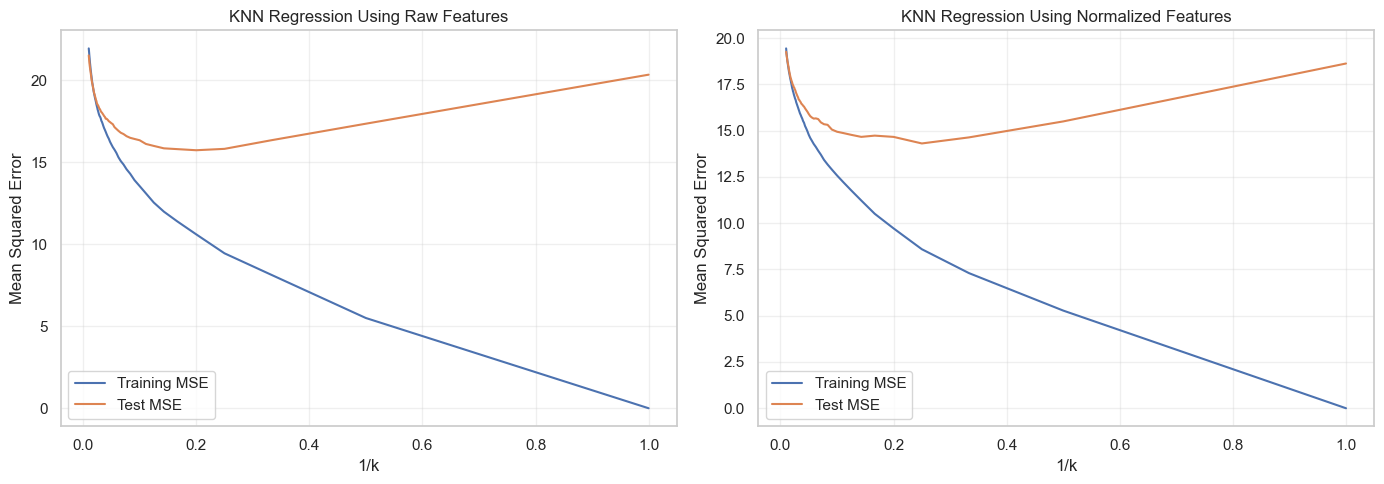

In [26]:
inverse_k = 1 / k_values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    inverse_k,
    raw_train_mse,
    label="Training MSE"
)
axes[0].plot(
    inverse_k,
    raw_test_mse,
    label="Test MSE"
)
axes[0].set_title("KNN Regression Using Raw Features")
axes[0].set_xlabel("1/k")
axes[0].set_ylabel("Mean Squared Error")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    inverse_k,
    normalized_train_mse,
    label="Training MSE"
)
axes[1].plot(
    inverse_k,
    normalized_test_mse,
    label="Test MSE"
)
axes[1].set_title("KNN Regression Using Normalized Features")
axes[1].set_xlabel("1/k")
axes[1].set_ylabel("Mean Squared Error")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
knn_results = pd.DataFrame({
    "Features": ["Raw", "Normalized"],
    "Best k": [best_raw_k, best_normalized_k],
    "Training MSE at best k": [
        raw_train_mse[best_raw_index],
        normalized_train_mse[best_normalized_index]
    ],
    "Test MSE at best k": [
        best_raw_test_mse,
        best_normalized_test_mse
    ]
})

display(knn_results.round(4))

,Features,Best k,Training MSE at best k,Test MSE at best k
0,Raw,5,10.6008,15.7268
1,Normalized,4,8.5914,14.3057


### KNN regression results

For the raw features, the lowest test MSE was 15.7268 at k = 5. For the
normalized features, the lowest test MSE was 14.3057 at k = 4.

The normalized KNN model performs better than the raw-feature model.
Normalization reduces the test MSE by approximately 9.04%. This improvement is expected because KNN uses distances between
observations. The predictors are measured in different units and have
different amounts of variability. Standardization places them on comparable
scales, preventing variables with larger spreads from dominating the
distance calculation.

At k = 1, the training MSE is zero because each training observation is its
own nearest neighbor. However, its test MSE is higher, indicating
overfitting. As k increases, the model becomes smoother. The test-error
curves initially decrease and then increase, showing the bias-variance
tradeoff.

## 1(j) Comparison of KNN and Linear Regression

In [28]:
final_comparison = pd.DataFrame({
    "Model": [
        "Standard linear regression",
        "Selected expanded regression",
        f"Raw KNN (k={best_raw_k})",
        f"Normalized KNN (k={best_normalized_k})"
    ],
    "Test MSE": [
        baseline_test_mse,
        expanded_test_mse,
        best_raw_test_mse,
        best_normalized_test_mse
    ]
}).sort_values("Test MSE")

display(final_comparison.round(4))

,Model,Test MSE
3,Normalized KNN (k=4),14.3057
2,Raw KNN (k=5),15.7268
1,Selected expanded regression,18.6600
0,Standard linear regression,21.2399


### Final model comparison

The normalized KNN model with k = 4 has the lowest test MSE of 14.3057 and
therefore provides the best predictive performance among the models
considered. The raw-feature KNN model with k = 5 has the second-lowest test
MSE of 15.7268.

Among the linear regression models, the selected expanded regression model
performs best, with a test MSE of 18.6600. This is lower than the standard
linear regression model's test MSE of 21.2399, demonstrating that quadratic
and interaction terms improve the linear regression model.

Nevertheless, both KNN models outperform the regression models on the test
set. The normalized KNN model captures local and nonlinear relationships
without requiring a specific functional form. Its disadvantage is that it
is less interpretable than linear regression. The expanded regression model
provides interpretable coefficients and information about specific
nonlinearities and interactions, but its predictive accuracy is lower.

Overall, normalized KNN with k = 4 is the preferred model when predictive
accuracy is the primary objective. The expanded regression model may be
preferred when interpretation of predictor effects is more important.

# Question 2 — ISLR Exercise 2.4.1

## (a) 
A flexible method is expected to perform better because the sample size is
extremely large relative to the number of predictors. The method has enough
observations to learn a complex relationship with less risk of overfitting.

## (b)
A flexible method is expected to perform worse because there are many
predictors but few observations. This creates a high risk of overfitting.

## (c)
A flexible method is expected to perform better because it can capture the
highly nonlinear relationship between the predictors and the response.

## (d)
A flexible method is expected to perform worse because the high error variance
means that much of the variation is noise. A flexible method may overfit this
noise.

# Question 3 — ISLR Exercise 2.4.7

## (a) Euclidean distances

The distance from an observation to the test point \((0,0,0)\) is:

$$
d = \sqrt{X_1^2 + X_2^2 + X_3^2}
$$

| Observation | Distance | Response |
|---|---:|---|
| 1 | $3$ | Red |
| 2 | $2$ | Red |
| 3 | $\sqrt{10} \approx 3.162$ | Red |
| 4 | $\sqrt{5} \approx 2.236$ | Green |
| 5 | $\sqrt{2} \approx 1.414$ | Green |
| 6 | $\sqrt{3} \approx 1.732$ | Red |

## (b) Prediction with K = 1

Observation 5 is the nearest neighbor and its response is Green. Therefore,
the prediction is **Green**.

## (c) Prediction with K = 3

The three nearest observations are Observation 5 (Green), Observation 6
(Red), and Observation 2 (Red). Red receives two of the three votes.
Therefore, the prediction is **Red**.

## (d) Nonlinear Bayes decision boundary

We would generally expect the best value of K to be small. A small K produces
a flexible decision boundary that can follow nonlinear patterns. A large K
creates a smoother and less flexible boundary that may underfit the nonlinear
relationship.